# Creating final data for crop and fertilizer recommendation system

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
fertilizer_data_path = '../Data-raw/FertilizerData.csv'
merge_fert = pd.read_csv(fertilizer_data_path)

In [3]:
merge_fert.head()

,Unnamed: 0,Crop,N,P,K,pH
0,0,rice,80,40,40,5.5
1,1,maize,80,40,20,5.5
2,2,chickpea,40,60,80,5.5
3,3,kidneybeans,20,60,20,5.5
4,4,pigeonpeas,20,60,20,5.5


In [4]:
del merge_fert['Unnamed: 0']

In [5]:
merge_fert.describe()

,N,P,K,pH
count,22.000000,22.000000,22.000000,22.000000
mean,50.454545,45.681818,48.181818,5.409091
std,36.315715,32.634172,51.698426,0.590326
min,20.000000,10.000000,10.000000,4.000000
25%,20.000000,20.000000,20.000000,5.500000
50%,30.000000,40.000000,30.000000,5.500000
75%,80.000000,60.000000,50.000000,5.500000
max,120.000000,125.000000,200.000000,6.500000


In [6]:
merge_fert['Crop'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

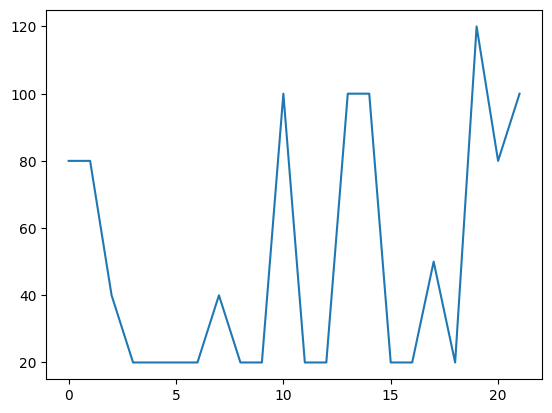

In [7]:
plt.plot(merge_fert["N"])

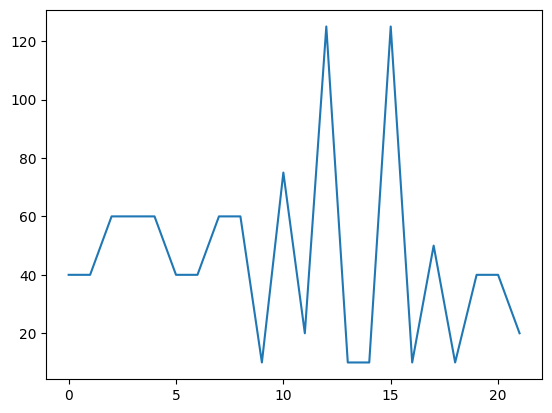

In [8]:
plt.plot(merge_fert["P"])

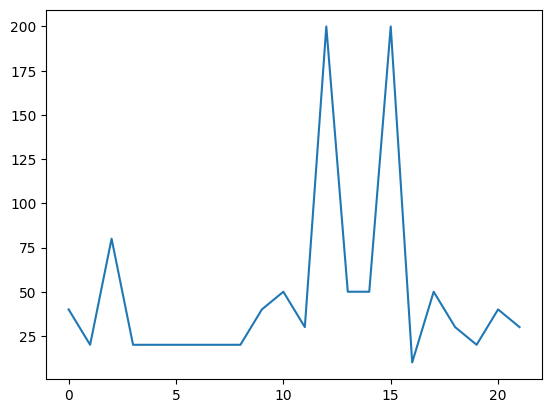

In [9]:
plt.plot(merge_fert["K"])

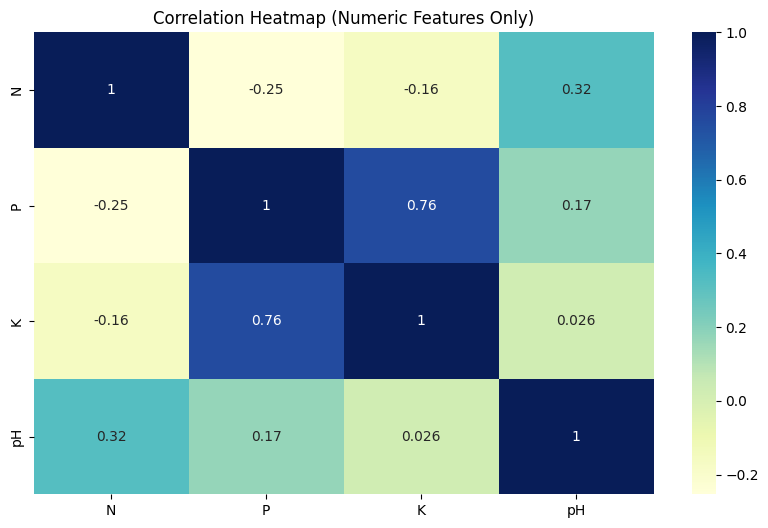

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Only include numeric columns for correlation
numeric_data = merge_fert.select_dtypes(include='number')

# Now draw heatmap
plt.figure(figsize=(10, 6))  # Optional: Adjust size
sns.heatmap(numeric_data.corr(), annot=True, cmap="YlGnBu")
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()


In [11]:
merge_crop = pd.read_csv('../Data-raw/MergeFileCrop.csv')
reco_fert = merge_fert

In [12]:
#Add +/-3 for every NPK value
import random
temp = pd.DataFrame(columns = ['N','P','K'])
for i in range(0,merge_crop.shape[0]):
    crop = merge_crop.label.iloc[i]
    #print(crop)
    N = reco_fert[reco_fert['Crop'] == crop]["N"].iloc[0] + random.randint(-20,20)
    P = reco_fert[reco_fert['Crop'] == crop]["P"].iloc[0] + random.randint(-5,20)
    K = reco_fert[reco_fert['Crop'] == crop]["K"].iloc[0] + random.randint(-5,5)
    d = {"N":N,"P":P,"K":K}
    #print(d)
    temp = pd.concat([temp, pd.DataFrame([d])], ignore_index=True)


In [13]:
temp

,N,P,K
0,71,51,41
1,78,50,45
2,71,35,37
3,74,55,38
4,86,45,38
...,...,...,...
2195,90,18,32
2196,81,29,32
2197,82,37,30
2198,113,37,35


In [14]:
merge_crop['N'] = temp['N']
merge_crop['P'] = temp['P']
merge_crop['K'] = temp['K']

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19652\4127802688.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  merge_crop['N'] = temp['N']
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19652\4127802688.py:2: FutureWarning: ChainedAssignmen

In [15]:
merge_crop

,Unnamed: 0,temperature,humidity,ph,rainfall,label,N,P,K
0,0,20.879744,82.002744,6.502985,202.935536,rice,71,51,41
1,1,21.770462,80.319644,7.038096,226.655537,rice,78,50,45
2,2,23.004459,82.320763,7.840207,263.964248,rice,71,35,37
3,3,26.491096,80.158363,6.980401,242.864034,rice,74,55,38
4,4,20.130175,81.604873,7.628473,262.717340,rice,86,45,38
...,...,...,...,...,...,...,...,...,...
2195,2195,26.774637,66.413269,6.780064,177.774507,coffee,90,18,32
2196,2196,27.417112,56.636362,6.086922,127.924610,coffee,81,29,32
2197,2197,24.131797,67.225123,6.362608,173.322839,coffee,82,37,30
2198,2198,26.272418,52.127394,6.758793,127.175293,coffee,113,37,35


In [16]:
del merge_crop['Unnamed: 0']

In [17]:
merge_crop

,temperature,humidity,ph,rainfall,label,N,P,K
0,20.879744,82.002744,6.502985,202.935536,rice,71,51,41
1,21.770462,80.319644,7.038096,226.655537,rice,78,50,45
2,23.004459,82.320763,7.840207,263.964248,rice,71,35,37
3,26.491096,80.158363,6.980401,242.864034,rice,74,55,38
4,20.130175,81.604873,7.628473,262.717340,rice,86,45,38
...,...,...,...,...,...,...,...,...
2195,26.774637,66.413269,6.780064,177.774507,coffee,90,18,32
2196,27.417112,56.636362,6.086922,127.924610,coffee,81,29,32
2197,24.131797,67.225123,6.362608,173.322839,coffee,82,37,30
2198,26.272418,52.127394,6.758793,127.175293,coffee,113,37,35


In [18]:
merge_crop = merge_crop[[ 'N', 'P', 'K','temperature', 'humidity', 'ph', 'rainfall', 'label']]

In [19]:
merge_crop.to_csv("../Data-processed/crop_recommendation.csv",index=False)

In [20]:
# Checking if everything went fine
df = pd.read_csv('../Data-processed/crop_recommendation.csv')

In [21]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,71,51,41,20.879744,82.002744,6.502985,202.935536,rice
1,78,50,45,21.770462,80.319644,7.038096,226.655537,rice
2,71,35,37,23.004459,82.320763,7.840207,263.964248,rice
3,74,55,38,26.491096,80.158363,6.980401,242.864034,rice
4,86,45,38,20.130175,81.604873,7.628473,262.717340,rice


In [22]:
df.shape

(2200, 8)